# Post-Conflict Constitutional Moments — Analysis

The post-conflict variable is the strongest predictor of constitutional recognition of ethnocultural diversity — stronger than colonial heritage.

**Unit of analysis:** The *current constitution's* adoption context, not the country as an inherent property.

**Criterion:** Constitution adopted as a direct result of a negotiated peace process, post-war/post-genocide transition, or post-liberation state-building. Coups, authoritarian revisions, and routine amendments are excluded.

**Result:** 15/54 coded as post-conflict. Heritage + post-conflict explain 54.9% of variance (vs heritage alone 22.3%).

In [1]:
import json
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

sys.path.insert(0, str(Path('..') / 'scripts'))
from figure_style import *

apply_style()

PROJECT = Path('..') if Path('../src/data.js').exists() else Path('.')

with open(PROJECT / 'src' / 'data.js') as f:
    DATA = json.loads(f.read().split('const DATA = ')[1].rstrip(';\n'))
with open(PROJECT / 'scripts' / 'post_conflict_coding.json') as f:
    pc_coding = json.load(f)

LABELS_DATA = DATA['feature_labels']

# Build DataFrame
rows = []
for row in DATA['feature_matrix']:
    c = row['PAYS']
    pc_info = pc_coding.get(c, {})
    rows.append({
        'country': c,
        'heritage': DATA['colonial_heritage'].get(c, 'other'),
        'post_conflict': pc_info.get('post_conflict', False) if isinstance(pc_info, dict) else pc_info,
        'const_year': pc_info.get('current_year') if isinstance(pc_info, dict) else None,
        'note': pc_info.get('note', '') if isinstance(pc_info, dict) else '',
        'total': sum(row[f] for f in FEATURES),
        **{f: row[f] for f in FEATURES}
    })
fm = pd.DataFrame(rows).set_index('country')
fm['pc_label'] = fm['post_conflict'].map({True: 'Post-conflit', False: 'Non-conflit'})

# Tier 1 subset
fa = fm[fm['heritage'].isin(['francophone', 'anglophone'])].copy()

print(f'Total: {len(fm)} countries, {fm["post_conflict"].sum()} post-conflict')
print(f'Tier 1: {len(fa)} countries (franco+anglo)')

Total: 54 countries, 13 post-conflict
Tier 1: 42 countries (franco+anglo)


## 1. Post-Conflict Coding Summary

In [2]:
# List all post-conflict constitutions with justification
pc_countries = fm[fm['post_conflict']].sort_values('total', ascending=False)
print(f'Post-conflict constitutions ({len(pc_countries)}/54):\n')
for name, row in pc_countries.iterrows():
    print(f'  {name:35s} [{row["heritage"]:12s}] score={row["total"]:2.0f}  year={row["const_year"]}  {row["note"]}')

# Crosstab
print('\nHeritage × post-conflict:')
print(pd.crosstab(fm['heritage'], fm['pc_label']))

Post-conflict constitutions (13/54):

  Kenya                               [anglophone  ] score=18  year=2010  Post-2007/2008 electoral violence (Kofi Annan mediation)
  Éthiopie                            [other       ] score=18  year=1994  Post-Derg — EPRDF armed liberation (1991)
  Soudan du Sud                       [anglophone  ] score=17  year=2011  Independence after Second Sudanese Civil War (CPA 2005)
  Afrique du Sud                      [anglophone  ] score=16  year=1996  Post-apartheid negotiated transition (CODESA/MPNP)
  Ouganda                             [anglophone  ] score=16  year=1995  Post-NRM civil war victory (1986), constituent assembly
  Zimbabwe                            [anglophone  ] score=16  year=2013  Global Political Agreement (2008) power-sharing after electoral crisis
  République démocratique du Congo    [francophone ] score=15  year=2006  Post-Second Congo War (Sun City agreement 2002)
  Somalie                             [other       ] score=15  

## 2. The 2×2 Interaction

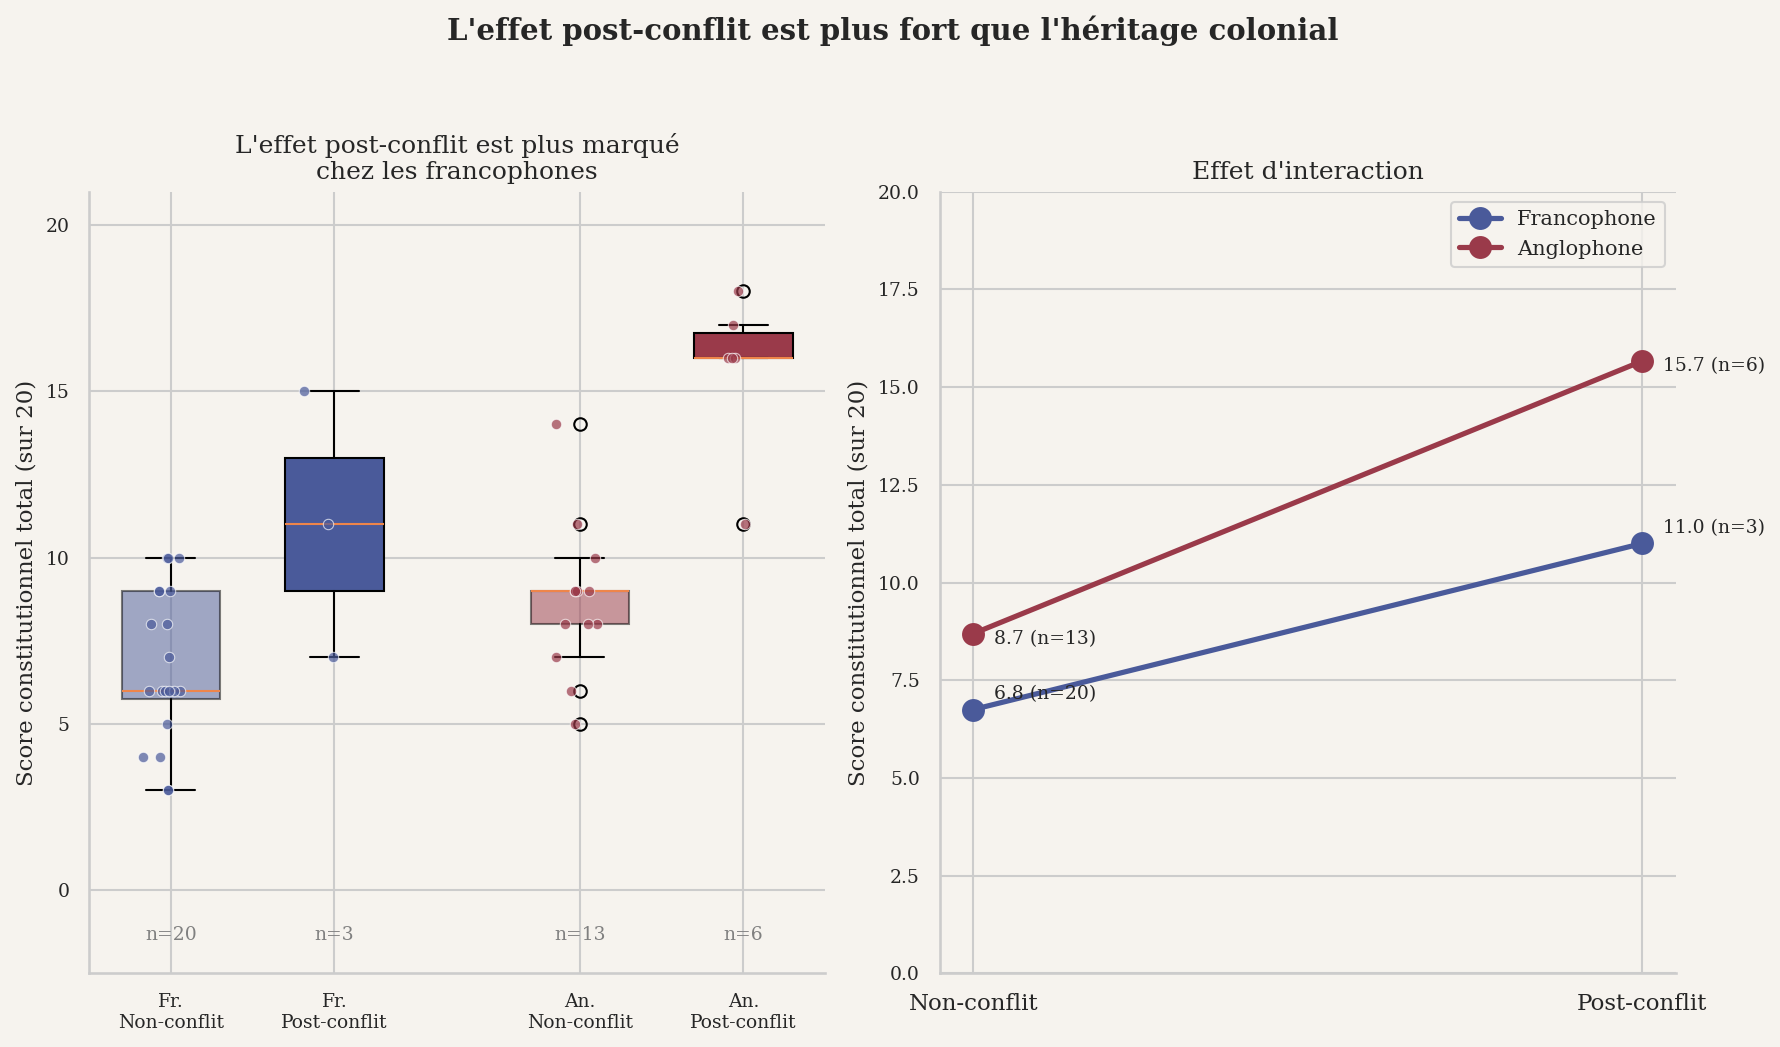

eta2 heritage alone:     0.223 (22.3%)
eta2 conflict alone:     0.510 (51.0%)
eta2 heritage+conflict:  0.632 (63.2%)


In [3]:
# FIGURE: 2x2 interaction plot (heritage x post-conflict)
# Data for the 4 groups (computed once)
group_data = [
    ('francophone', False), ('francophone', True),
    ('anglophone', False), ('anglophone', True),
]
positions = [0, 1, 2.5, 3.5]

for lang in ('fr', 'en'):
    pc_non = t('pc_non_conflict', lang)
    pc_post = t('pc_post_conflict', lang)

    box_labels = [
        f'Fr.\n{pc_non}', f'Fr.\n{pc_post}',
        f'An.\n{pc_non}', f'An.\n{pc_post}',
    ]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7))

    # Overarching finding title
    fig.suptitle(t('pc_interaction_suptitle', lang), fontsize=14, fontweight='bold',
                 fontfamily='serif', y=0.99)

    # Left: box plot
    for i, ((h, pc), pos, label) in enumerate(zip(group_data, positions, box_labels)):
        data = fa[(fa['heritage'] == h) & (fa['post_conflict'] == pc)]['total']
        alpha = 1.0 if pc else 0.5
        bp = ax1.boxplot([data.values], positions=[pos], widths=0.6, patch_artist=True)
        bp['boxes'][0].set_facecolor(HC[h])
        bp['boxes'][0].set_alpha(alpha)
        jitter = np.random.normal(0, 0.08, len(data))
        ax1.scatter([pos] * len(data) + jitter, data.values,
                   c=HC[h], s=25, alpha=0.7, edgecolors='white', linewidth=0.5, zorder=3)
        ax1.text(pos, -1.5, f'n={len(data)}', ha='center', fontsize=9, color='gray')

    ax1.set_xticks(positions)
    ax1.set_xticklabels(box_labels, fontsize=9, rotation=0, ha='center')
    ax1.set_ylabel(t('pc_interaction_ylabel', lang))
    ax1.set_ylim(-2.5, 21)
    ax1.set_title(t('pc_interaction_title', lang), fontsize=12)

    # Right: interaction line plot (means)
    for h, color in [('francophone', HC['francophone']), ('anglophone', HC['anglophone'])]:
        means = []
        for pc in [False, True]:
            subset = fa[(fa['heritage'] == h) & (fa['post_conflict'] == pc)]
            means.append(subset['total'].mean() if len(subset) > 0 else np.nan)
        ax2.plot([0, 1], means, 'o-', color=color, linewidth=2.5, markersize=10, label=hl(h, lang))
        for j, (m, pc) in enumerate(zip(means, [False, True])):
            n = len(fa[(fa['heritage'] == h) & (fa['post_conflict'] == pc)])
            if not np.isnan(m):
                ax2.annotate(f'{m:.1f} (n={n})', (j, m), fontsize=9,
                            xytext=(10, -5 if h == 'anglophone' else 5), textcoords='offset points')

    ax2.set_xticks([0, 1])
    ax2.set_xticklabels([pc_non, pc_post], fontsize=11)
    ax2.set_ylabel(t('pc_interaction_ylabel', lang))
    ax2.set_title(t('pc_interaction_effect', lang), fontsize=12)
    ax2.legend(fontsize=10)
    ax2.set_ylim(0, 20)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    save_fig(fig, 'post_conflict_interaction', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

# Statistics
gm = fa['total'].mean()
ss_t = ((fa['total'] - gm)**2).sum()
ss_h = sum(len(fa[fa['heritage']==h]) * (fa[fa['heritage']==h]['total'].mean() - gm)**2 for h in ['francophone','anglophone'])
ss_pc = sum(len(fa[fa['post_conflict']==v]) * (fa[fa['post_conflict']==v]['total'].mean() - gm)**2 for v in [True, False])
fa['cell'] = fa['heritage'] + '_' + fa['post_conflict'].astype(str)
cell_m = fa.groupby('cell')['total'].mean()
ss_cells = sum(len(fa[fa['cell']==c]) * (cell_m[c] - gm)**2 for c in cell_m.index)

print(f'eta2 heritage alone:     {ss_h/ss_t:.3f} ({ss_h/ss_t*100:.1f}%)')
print(f'eta2 conflict alone:     {ss_pc/ss_t:.3f} ({ss_pc/ss_t*100:.1f}%)')
print(f'eta2 heritage+conflict:  {ss_cells/ss_t:.3f} ({ss_cells/ss_t*100:.1f}%)')

## 3. Per-Dimension Breakdown

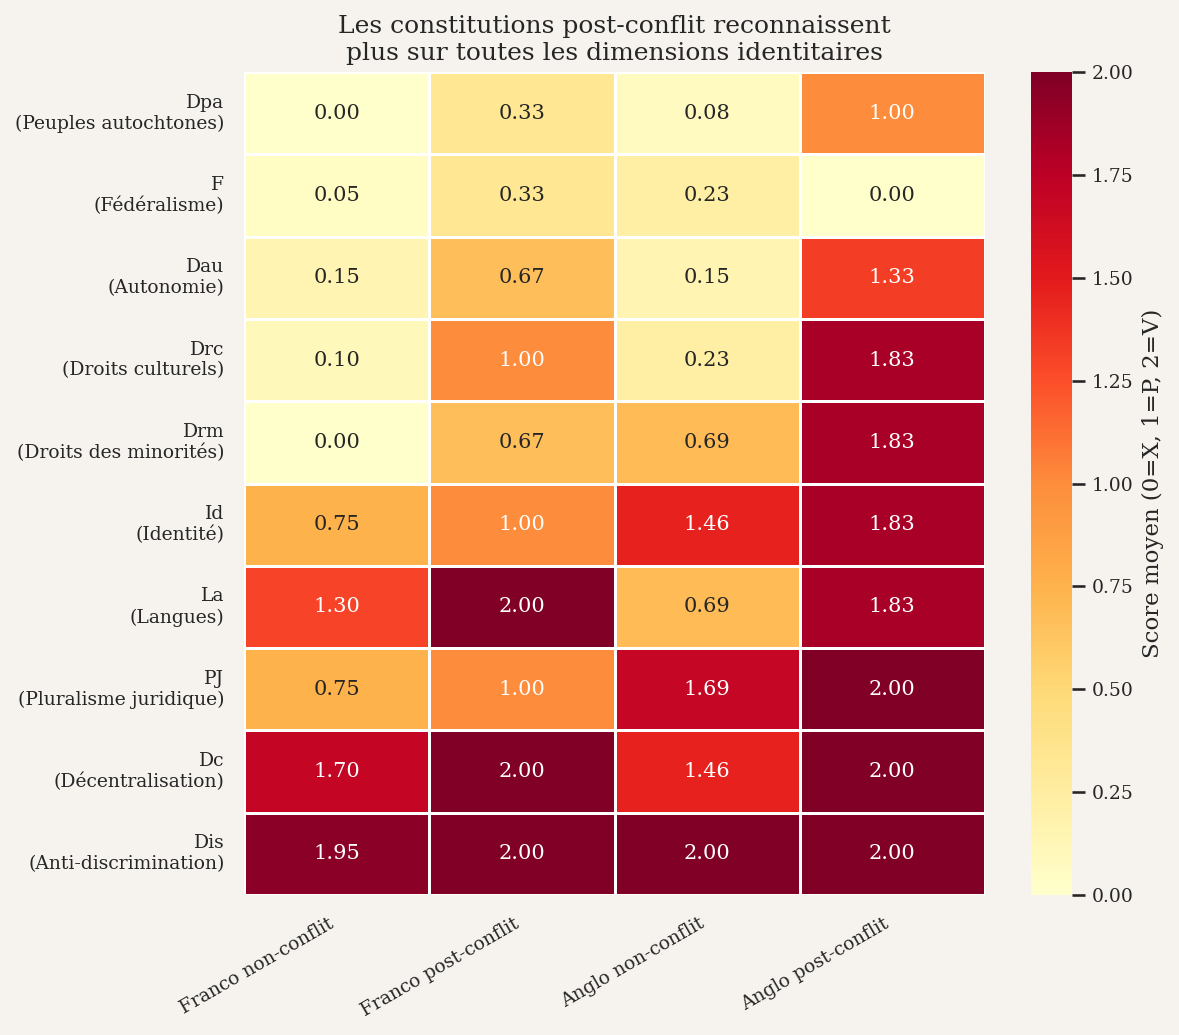

Per-dimension conflict effect (Tier 1, n=42):
Dim    F+conf    F+non   A+conf    A+non  Conflict p
Dpa      0.33     0.00     1.00     0.08      0.0000 ***
F        0.33     0.05     0.00     0.23      0.9041 ns
Dau      0.67     0.15     1.33     0.15      0.0001 ***
Drc      1.00     0.10     1.83     0.23      0.0000 ***
Drm      0.67     0.00     1.83     0.69      0.0001 ***
Id       1.00     0.75     1.83     1.46      0.0561 ns
La       2.00     1.30     1.83     0.69      0.0120 *
PJ       1.00     0.75     2.00     1.69      0.0951 ns
Dc       2.00     1.70     2.00     1.46      0.0868 ns
Dis      2.00     1.95     2.00     2.00      0.6425 ns


In [4]:
# FIGURE: Per-dimension heatmap — transposed: dimensions as rows, 4 groups as columns
# Compute data once
cells_data = [
    ('francophone', False), ('francophone', True),
    ('anglophone', False), ('anglophone', True),
]
cell_subsets = {(h, pc): fa[(fa['heritage'] == h) & (fa['post_conflict'] == pc)] for h, pc in cells_data}

for lang in ('fr', 'en'):
    row_labels = t('pc_row_labels', lang)
    dim_labels = t('dim', lang)

    cell_means = pd.DataFrame(
        {label: cell_subsets[(h, pc)][FEATURES].mean() for label, (h, pc) in zip(row_labels, cells_data)}
    ).T
    cell_means.columns = [f'{f}\n({dim_labels[f]})' for f in FEATURES]

    # Transpose: dimensions as rows, groups as columns — better readability
    cell_means_T = cell_means.T

    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(cell_means_T, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=2,
                linewidths=0.5, ax=ax, cbar_kws={'label': t('pc_dimensions_cbar', lang)})
    ax.set_title(t('pc_dimensions_title', lang), fontsize=12)
    ax.set_ylabel('')
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=9, rotation=30, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)

    plt.tight_layout()
    save_fig(fig, 'post_conflict_dimensions', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

# Per-dimension conflict effect test (within Tier 1)
print('Per-dimension conflict effect (Tier 1, n=42):')
print(f'{"Dim":4s}  {"F+conf":>7s}  {"F+non":>7s}  {"A+conf":>7s}  {"A+non":>7s}  {"Conflict p":>10s}')
for f in FEATURES:
    fc = fa[(fa['heritage']=='francophone') & (fa['post_conflict'])][f].mean()
    fn = fa[(fa['heritage']=='francophone') & (~fa['post_conflict'])][f].mean()
    ac = fa[(fa['heritage']=='anglophone') & (fa['post_conflict'])][f].mean()
    an = fa[(fa['heritage']=='anglophone') & (~fa['post_conflict'])][f].mean()
    conf = fa[fa['post_conflict']][f].values
    noconf = fa[~fa['post_conflict']][f].values
    _, p = stats.mannwhitneyu(conf, noconf, alternative='two-sided')
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f'{f:4s}  {fc:7.2f}  {fn:7.2f}  {ac:7.2f}  {an:7.2f}  {p:10.4f} {sig}')

## D1. The Outliers Explained

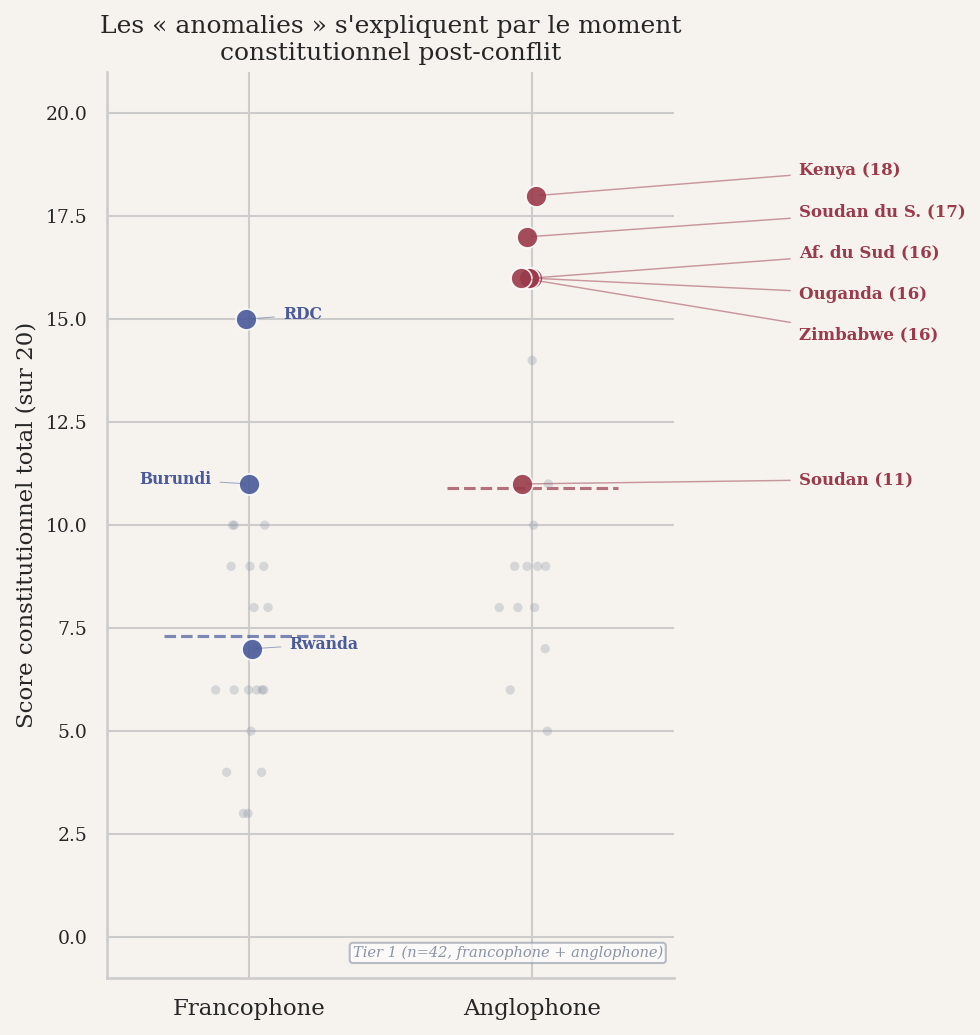

In [5]:
# FIGURE D1: "The Outliers Explained" — strip plot
# Post-conflict countries as labeled outliers within each heritage group

# Anglophone dense cluster: countries with scores 16-18 that would overlap
ANGLO_CLUSTER = {'Kenya', 'Afrique du Sud', 'Soudan du Sud', 'Ouganda', 'Zimbabwe'}

# Display name mapping
DISPLAY_NAMES = {
    'République démocratique du Congo': 'RDC',
    'Afrique du Sud': 'Af. du Sud',
    'Soudan du Sud': 'Soudan du S.',
}

for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(7, 7))

    # Heritage group positions
    h_pos = {'francophone': 0, 'anglophone': 1}

    for h in TIER1_HERITAGES:
        pos = h_pos[h]
        non_pc = fa[(fa['heritage'] == h) & (~fa['post_conflict'])]
        pc = fa[(fa['heritage'] == h) & (fa['post_conflict'])]

        # Layer 1: non-conflict countries — small gray dots with jitter
        jitter = np.random.default_rng(42).normal(0, 0.06, len(non_pc))
        ax.scatter([pos] * len(non_pc) + jitter, non_pc['total'],
                   s=20, alpha=0.3, color=C_DIM, edgecolors='none', zorder=2)

        # Layer 2: post-conflict countries — large colored dots
        jitter_pc = np.random.default_rng(7).normal(0, 0.04, len(pc))
        ax.scatter([pos] * len(pc) + jitter_pc, pc['total'],
                   s=100, alpha=0.9, color=HC[h], edgecolors='white', linewidth=0.8, zorder=3)

        if h == 'anglophone':
            # Leader-line labels: each country name placed to the right, stacked vertically
            all_pc = pc.sort_values('total', ascending=False)
            stacked_ys = [18.5, 17.5, 16.5, 15.5, 14.5]
            for idx_lbl, (name, row) in enumerate(all_pc.iterrows()):
                display = DISPLAY_NAMES.get(name, name)
                jit_idx = pc.index.get_loc(name)
                dot_x = pos + jitter_pc[jit_idx]
                stacked_y = stacked_ys[idx_lbl] if idx_lbl < len(stacked_ys) else row['total']
                ax.annotate(f'{display} ({int(row["total"])})',
                            xy=(dot_x, row['total']),
                            xytext=(1.22, stacked_y),
                            textcoords=('axes fraction', 'data'),
                            fontsize=8, color=HC[h], fontweight='bold',
                            arrowprops=dict(arrowstyle='-', color=HC[h], lw=0.7, alpha=0.5))

        else:
            # Francophone: label individually (RDC=15, Burundi=11, Rwanda=7 — well separated)
            pc_sorted = pc.sort_values('total', ascending=True)
            for idx, (name, row) in enumerate(pc_sorted.iterrows()):
                display = DISPLAY_NAMES.get(name, name)
                x_off = 18 if idx % 2 == 0 else -18
                ha = 'left' if idx % 2 == 0 else 'right'
                jit_idx = pc.index.get_loc(name)
                ax.annotate(display, (pos + jitter_pc[jit_idx], row['total']),
                           fontsize=7.5, color=HC[h], fontweight='bold',
                           xytext=(x_off, 0), textcoords='offset points', ha=ha,
                           arrowprops=dict(arrowstyle='-', color=HC[h], lw=0.5, alpha=0.5))

        # Heritage group mean line
        group_mean = fa[fa['heritage'] == h]['total'].mean()
        ax.hlines(group_mean, pos - 0.3, pos + 0.3,
                  colors=HC[h], linestyles='dashed', linewidth=1.5, alpha=0.7, zorder=1)

    ax.set_xticks([0, 1])
    ax.set_xticklabels([hl('francophone', lang), hl('anglophone', lang)], fontsize=11)
    ax.set_ylabel(t('pc_outliers_ylabel', lang))
    ax.set_title(t('pc_outliers_title', lang), fontsize=12)
    ax.set_ylim(-1, 21)
    ax.set_xlim(-0.5, 1.5)

    add_tier_note(ax, lang)
    plt.tight_layout()
    save_fig(fig, 'post_conflict_outliers_explained', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)


## D2. The Mechanism

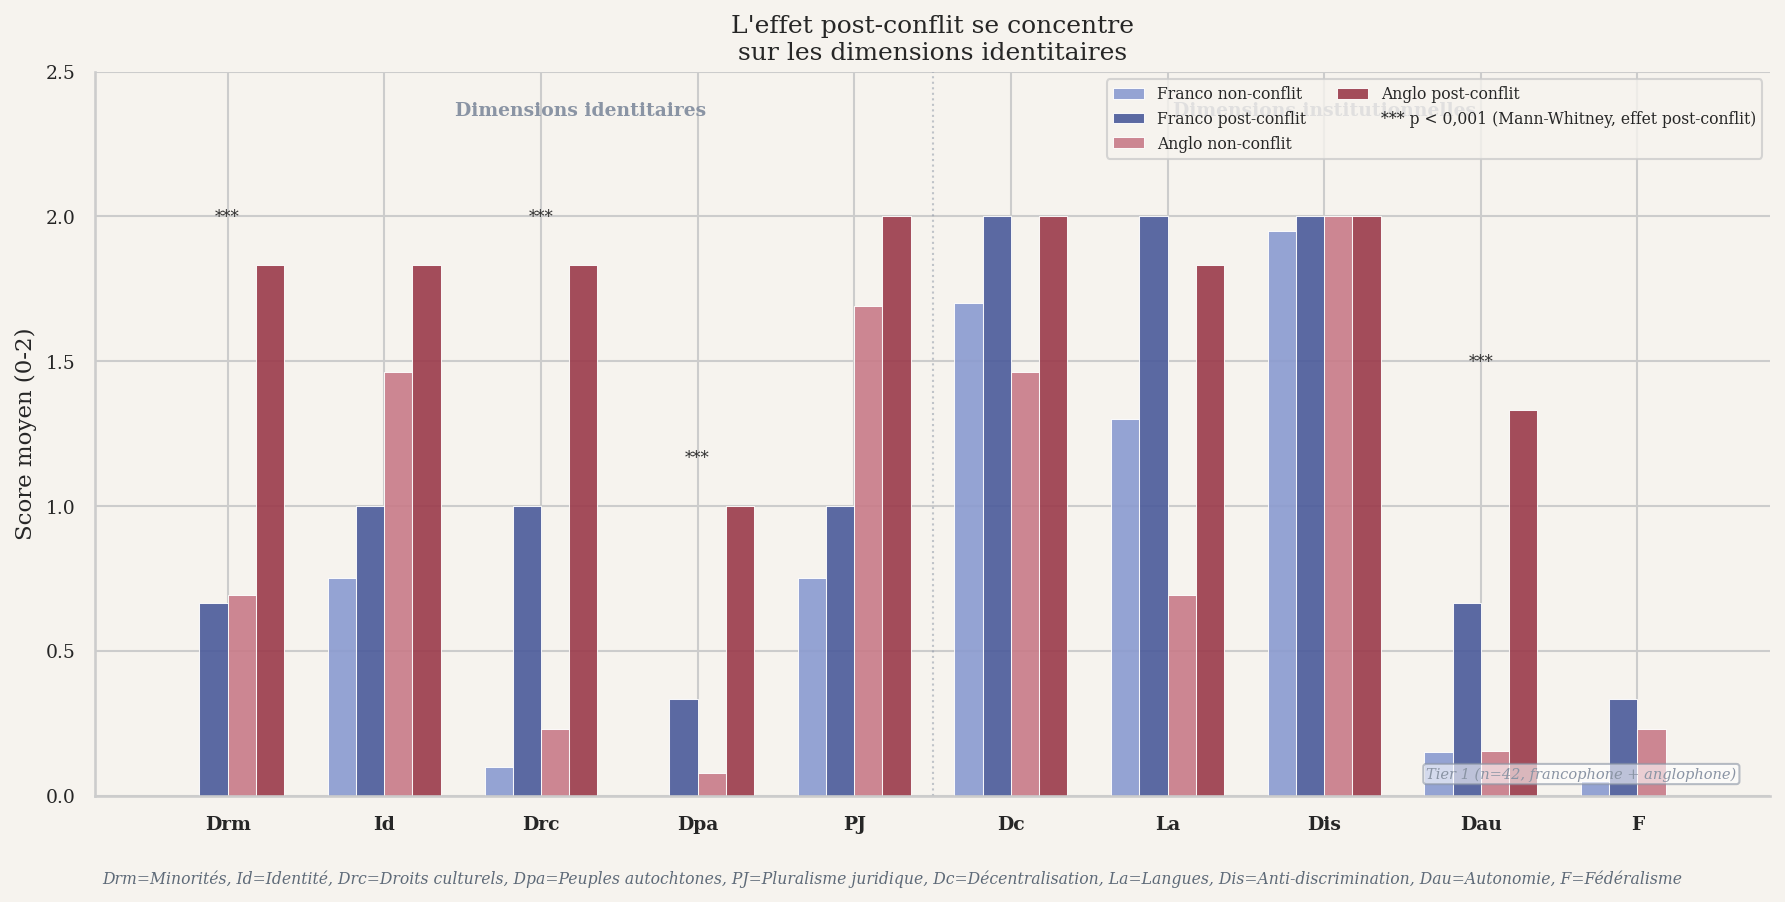

In [6]:
# FIGURE D2: "The Mechanism" — per-dimension grouped bar chart
# Shows which dimensions drive the post-conflict effect
dim_order = IDENTITY_DIMS + INSTITUTIONAL_DIMS
n_dims = len(dim_order)
n_identity = len(IDENTITY_DIMS)

# Colors: light = non-conflict, dark = post-conflict
colors_4 = [
    '#8a9ad0',  # franco non (light blue)
    HC['francophone'],  # franco post (dark blue)
    '#c87a88',  # anglo non (light burgundy)
    HC['anglophone'],  # anglo post (dark burgundy)
]

for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(12, 6))
    dim_labels = t('dim', lang)

    # Compute means for 4 groups
    groups = [
        ('francophone', False),
        ('francophone', True),
        ('anglophone', False),
        ('anglophone', True),
    ]
    group_labels = t('pc_row_labels', lang)
    group_means = {}
    for (h, pc), label in zip(groups, group_labels):
        subset = fa[(fa['heritage'] == h) & (fa['post_conflict'] == pc)]
        group_means[label] = [subset[d].mean() if len(subset) > 0 else 0 for d in dim_order]

    # Bar positions
    bar_width = 0.18
    x = np.arange(n_dims)

    for i, (label, color) in enumerate(zip(group_labels, colors_4)):
        offset = (i - 1.5) * bar_width
        ax.bar(x + offset, group_means[label], bar_width, label=label,
               color=color, edgecolor='white', linewidth=0.5, alpha=0.9)

    # Vertical separator between identity and institutional groups
    sep_x = n_identity - 0.5
    ax.axvline(sep_x, color=C_DIM, linestyle=':', linewidth=1, alpha=0.5)

    # Column headers ABOVE the bars (not overlapping)
    ax.text(sep_x / 2, 2.35, t('pc_mechanism_identity', lang),
            ha='center', fontsize=9, color=C_DIM, fontweight='bold')
    ax.text(sep_x + (n_dims - n_identity) / 2, 2.35, t('pc_mechanism_institutional', lang),
            ha='center', fontsize=9, color=C_DIM, fontweight='bold')

    # Significance stars for dimensions with p<0.001 — position higher to avoid bar overlap
    sig_dims = {'Dpa', 'Dau', 'Drc', 'Drm'}
    for j, d in enumerate(dim_order):
        if d in sig_dims:
            max_val = max(group_means[lbl][j] for lbl in group_labels)
            ax.text(j, max_val + 0.15, '***', ha='center', fontsize=8, color='#333')

    # Use abbreviated dimension codes on x-axis
    ax.set_xticks(x)
    ax.set_xticklabels(dim_order, fontsize=9, fontweight='bold')
    ax.set_ylabel(t('pc_mechanism_ylabel', lang))
    ax.set_title(t('pc_mechanism_title', lang), fontsize=12)
    ax.set_ylim(0, 2.5)

    # Legend: 4 groups + significance explanation
    handles, labels = ax.get_legend_handles_labels()
    # Add *** explanation to legend
    sig_patch = Line2D([0], [0], marker='', color='none', label=t('pc_mechanism_sig_legend', lang))
    handles.append(sig_patch)
    ax.legend(handles=handles, fontsize=7.5, ncol=2, loc='upper right')

    # Footnote mapping codes to full names — increased fontsize for readability
    fig.text(0.5, 0.01, t('pc_mechanism_footnote', lang),
             ha='center', fontsize=7.5, color=C_MUTED, style='italic')

    # Tier 1 note in bottom-right corner
    ax.text(0.98, 0.02, t('tier1_note', lang), transform=ax.transAxes, ha='right', va='bottom',
            fontsize=7, color=C_DIM, style='italic',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor=C_DIM, alpha=0.6))

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    save_fig(fig, 'post_conflict_mechanism', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)


## 4. Preamble Rhetoric by Post-Conflict Status

In [7]:
# Do post-conflict preambles have more identity rhetoric?
with open(PROJECT / 'scripts' / 'country_mapping.json') as f:
    EN_TO_FR = json.load(f)
FR_TO_EN = {v: k for k, v in EN_TO_FR.items()}

PREAMBLE_DIR = PROJECT / 'data' / 'preamble_corpus'

SOV_KW = ['sovereignty', 'sovereign', 'unity', 'indivisible', 'territorial integrity', 'national unity', 'unitary']
ID_KW = ['people', 'peoples', 'ethnic', 'tribe', 'tribal', 'diversity', 'community', 'communities',
         'indigenous', 'minority', 'minorities', 'identity', 'tradition', 'cultural heritage', 'customary']

def count_kw(text, keywords):
    t = text.lower()
    return sum(len(re.findall(r'\b' + re.escape(kw) + r'\b', t)) for kw in keywords)

preamble_rows = []
for name, row in fm.iterrows():
    en_name = FR_TO_EN.get(name)
    if not en_name:
        continue
    # Find preamble file
    candidates = list(PREAMBLE_DIR.glob(f'{en_name.replace(" ", "_")}*.txt'))
    if not candidates:
        continue
    text = candidates[0].read_text(encoding='utf-8')
    n_words = len(text.split())
    if n_words < 20:
        continue
    preamble_rows.append({
        'country': name, 'heritage': row['heritage'], 'post_conflict': row['post_conflict'],
        'sov': count_kw(text, SOV_KW) / n_words * 1000,
        'id': count_kw(text, ID_KW) / n_words * 1000,
    })

pa = pd.DataFrame(preamble_rows)

# Compare
print('Preamble rhetoric by post-conflict status:')
for pc in [True, False]:
    subset = pa[pa['post_conflict'] == pc]
    label = 'Post-conflit' if pc else 'Non-conflit'
    print(f'  {label:15s} (n={len(subset)}): sovereignty={subset["sov"].mean():.1f}, identity={subset["id"].mean():.1f}')

# Within francophone only (Tier 1)
print('\nWithin francophone:')
for pc in [True, False]:
    subset = pa[(pa['heritage']=='francophone') & (pa['post_conflict']==pc)]
    label = 'Post-conflit' if pc else 'Non-conflit'
    if len(subset) > 0:
        print(f'  {label:15s} (n={len(subset)}): sovereignty={subset["sov"].mean():.1f}, identity={subset["id"].mean():.1f}')

Preamble rhetoric by post-conflict status:
  Post-conflit    (n=12): sovereignty=9.6, identity=12.8
  Non-conflit     (n=37): sovereignty=11.5, identity=14.7

Within francophone:
  Post-conflit    (n=3): sovereignty=11.4, identity=8.9
  Non-conflit     (n=20): sovereignty=13.3, identity=14.7


## 5. Summary

In [8]:
print('='*60)
print('POST-CONFLICT ANALYSIS SUMMARY')
print('='*60)
print(f'\n  Post-conflict constitutions: {fa["post_conflict"].sum()}/{len(fa)} (Tier 1)')
print(f'  Post-conflict mean score: {fa[fa["post_conflict"]]["total"].mean():.1f}/20')
print(f'  Non-conflict mean score:  {fa[~fa["post_conflict"]]["total"].mean():.1f}/20')
print(f'  Mann-Whitney p = {stats.mannwhitneyu(fa[fa["post_conflict"]]["total"], fa[~fa["post_conflict"]]["total"]).pvalue:.4f}')
print(f'\n  η² heritage alone:     {ss_h/ss_t:.3f} ({ss_h/ss_t*100:.1f}%)')
print(f'  η² conflict alone:     {ss_pc/ss_t:.3f} ({ss_pc/ss_t*100:.1f}%)')
print(f'  η² heritage+conflict:  {ss_cells/ss_t:.3f} ({ss_cells/ss_t*100:.1f}%)')
print(f'\n  Key thesis implication:')
print(f'  Post-conflict constitutional moments drive recognition of sub-state')
print(f'  peoples more than inherited legal tradition. This supports the functional')
print(f'  criterion: recognition emerges from political necessity, not from')
print(f'  doctrinal tradition alone.')
print(f'\n  Figures: {list(FIG_DIR.glob("post_conflict_*"))}')

POST-CONFLICT ANALYSIS SUMMARY

  Post-conflict constitutions: 9/42 (Tier 1)
  Post-conflict mean score: 14.1/20
  Non-conflict mean score:  7.5/20
  Mann-Whitney p = 0.0001

  η² heritage alone:     0.223 (22.3%)
  η² conflict alone:     0.510 (51.0%)
  η² heritage+conflict:  0.632 (63.2%)

  Key thesis implication:
  Post-conflict constitutional moments drive recognition of sub-state
  peoples more than inherited legal tradition. This supports the functional
  criterion: recognition emerges from political necessity, not from
  doctrinal tradition alone.

  Figures: []
